# RAISE-26: AI对人类行为影响的多标签文本分类 - 完整NLP Pipeline

## 📋 项目概述

**研究问题**: AI正在如何改变人类的思考、行动和互动方式？

**方法**: 使用NLP技术分析AI相关新闻标题，识别其中涉及的人类行为影响维度。

---

## 🔄 Pipeline结构

| 阶段 | 内容 | 目的 |
|------|------|------|
| 1 | 环境设置 | 安装依赖、导入库 |
| 2 | 数据加载与探索 | 理解数据分布 |
| 3 | 数据预处理 | 文本清洗、标签处理 |
| 4 | 多标签编码与划分 | 创建训练/验证/测试集 |
| 5 | Baseline模型 | TF-IDF + Logistic Regression |
| 6 | 深度学习模型 | DistilBERT多标签分类器 |
| 7 | 模型评估与对比 | F1-score、混淆矩阵 |
| 8 | 可解释性分析 | 高权重特征、错误分析 |
| 9 | 主题建模 | NMF发现潜在主题 |
| 10 | Dataset C分析 | 应用模型分析LLM输出 |
| 11 | 结论与洞察 | 总结发现 |

---
# 阶段 1: 环境设置

**目标**: 安装必要的依赖包，设置随机种子确保可复现性。

In [7]:
# ============================================================
# 1.1 安装依赖（Colab环境）
# ============================================================
# 如果在Colab中运行，取消注释以下行
# !pip -q install -U nltk iterative-stratification
# !pip -q install -U transformers datasets accelerate

# 本地环境安装
# pip install pandas numpy matplotlib seaborn nltk scikit-learn transformers torch accelerate iterative-stratification

In [8]:
# ============================================================
# 1.2 导入所有必要的库
# ============================================================

# 基础库
import os
import re
import json
import warnings
from typing import List, Dict, Optional, Tuple

# 数据处理
import numpy as np
import pandas as pd

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

# NLP工具
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score
)
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans

# 多标签分层采样
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    ITERSTRAT_AVAILABLE = True
except ImportError:
    ITERSTRAT_AVAILABLE = False
    print("警告: iterative-stratification未安装，将使用普通随机划分")

# 深度学习
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Transformers
from transformers import (
    DistilBertTokenizer,
    DistilBertModel,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# 设置
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 100)

print("✓ 所有库导入成功！")

警告: iterative-stratification未安装，将使用普通随机划分
✓ 所有库导入成功！


In [9]:
# ============================================================
# 1.3 设置随机种子（确保可复现性）
# ============================================================

SEED = 42

def set_seed(seed: int = 42):
    """设置所有随机种子以确保可复现性"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # 设置确定性算法
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# 检测设备
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ 随机种子设置为: {SEED}")
print(f"✓ 使用设备: {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

✓ 随机种子设置为: 42
✓ 使用设备: cpu


In [10]:
# ============================================================
# 1.4 配置文件路径
# ============================================================

# 根据环境选择路径
PATH_CANDIDATES_A = [
    'dataset_A_news_full_10500.csv',
    '/content/dataset_A_news_full_10500.csv',  # Colab
    '/mnt/data/dataset_A_news_full_10500.csv'   # 其他环境
]

PATH_CANDIDATES_C = [
    'Dataset_C_prompts_&_queries.csv',
    '/content/Dataset_C_prompts_&_queries.csv',
    '/mnt/data/Dataset_C_prompts_&_queries.csv'
]

def find_file(candidates: List[str]) -> str:
    """从候选路径中找到存在的文件"""
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"未找到文件，请检查以下路径: {candidates}")

# 列名配置
TEXT_COL = 'title'
LABEL_COL = 'classes_str'

print("✓ 路径配置完成")

✓ 路径配置完成


---
# 阶段 2: 数据加载与探索

**目标**: 加载Dataset A，理解数据结构和标签分布。

In [11]:
# ============================================================
# 2.1 加载Dataset A
# ============================================================

try:
    PATH_A = find_file(PATH_CANDIDATES_A)
    dfA = pd.read_csv(PATH_A)
    print(f"✓ 数据加载成功: {PATH_A}")
    print(f"  数据形状: {dfA.shape}")
    print(f"  列名: {list(dfA.columns)}")
except FileNotFoundError as e:
    print(f"⚠️ {e}")
    print("请上传 dataset_A_news_full_10500.csv 文件")

✓ 数据加载成功: dataset_A_news_full_10500.csv
  数据形状: (10500, 12)
  列名: ['title', 'link', 'date', 'source', 'number_of_characters_title', 'number_of_words_title', 'day_of_week', 'month', 'year', 'quarter', 'is_weekend', 'classes_str']


In [12]:
# ============================================================
# 2.2 数据预览
# ============================================================

print("=" * 60)
print("数据预览 (前5行)")
print("=" * 60)
display(dfA.head())

print("\n" + "=" * 60)
print("数据类型")
print("=" * 60)
print(dfA.dtypes)

数据预览 (前5行)


,title,link,date,source,number_of_characters_title,number_of_words_title,day_of_week,month,year,quarter,is_weekend,classes_str
0,"Google’s AI is the ‘worst’ for stealing content, says People CEO",https://news.google.com/rss/articles/CBMipgFBVV95cUxNY0lCNkcyS21vamMyM0UzWFFxdDV3dzZZQVlFNUZMY3p...,2025-09-11,Fortune,74,13,Thursday,September,2025,3,False,"Sentiment (Positive / Negative Feelings); Human Roles; Society, Ethics & Culture"
1,Powering the Next Wave of Enterprise Innovation: Mesh-AI Named OpenAI UK Services Partner,https://news.google.com/rss/articles/CBMitgFBVV95cUxOYlNnckMtdVR5Z2RRSnh5VlY5NURkRlN6VHlIRG9OM3A...,2025-09-11,Silicon Canals,106,16,Thursday,September,2025,3,False,"Creativity, Expression & Identity; Work, Jobs & Economy"
2,AI a ‘strategic necessity’ law lecturer says,https://news.google.com/rss/articles/CBMiiAFBVV95cUxNMTFybTAyLWZqRk83RlJyUm4yLWtCY2pjT29NY2tjM0F...,2025-09-11,qlsproctor.com.au,64,9,Thursday,September,2025,3,False,"Society, Ethics & Culture"
3,Datacom sees AI agents as pivotal to legacy app modernisation,https://news.google.com/rss/articles/CBMirAFBVV95cUxQTEh5dy12NTd0X0VFNjh1WTlNbE9OU0lCcFZXS3lKYXh...,2025-09-11,ARNnet,70,12,Thursday,September,2025,3,False,"Routine, Lifestyle & Behavior"
4,"Student Blog: Startups, AI, and Lessons from Singapore",https://news.google.com/rss/articles/CBMijwFBVV95cUxNS3pPT2pWOFZmOTVESDhEaE41eE8wNUZRT1pmdlphRGZ...,2025-09-11,The University of Queensland,85,13,Thursday,September,2025,3,False,"Learning, Knowledge & Education"



数据类型
title                         object
link                          object
date                          object
source                        object
number_of_characters_title     int64
number_of_words_title          int64
day_of_week                   object
month                         object
year                           int64
quarter                        int64
is_weekend                      bool
classes_str                   object
dtype: object


In [13]:
# ============================================================
# 2.3 标签分析 - 解析多标签
# ============================================================

# 清洗标签列
dfA[LABEL_COL] = dfA[LABEL_COL].fillna('').astype(str)

# 解析分号分隔的多标签
def parse_labels(label_str: str) -> List[str]:
    """解析分号分隔的标签字符串"""
    if not label_str or label_str == 'nan':
        return []
    return [l.strip() for l in label_str.split(';') if l.strip()]

dfA['labels_list'] = dfA[LABEL_COL].apply(parse_labels)
dfA['num_labels'] = dfA['labels_list'].apply(len)

# 统计所有唯一标签
all_labels = [label for labels in dfA['labels_list'] for label in labels]
label_counts = pd.Series(all_labels).value_counts()

print(f"✓ 标签解析完成")
print(f"  总样本数: {len(dfA)}")
print(f"  唯一标签数: {len(label_counts)}")
print(f"  每样本平均标签数: {dfA['num_labels'].mean():.2f}")

✓ 标签解析完成
  总样本数: 10500
  唯一标签数: 12
  每样本平均标签数: 1.54


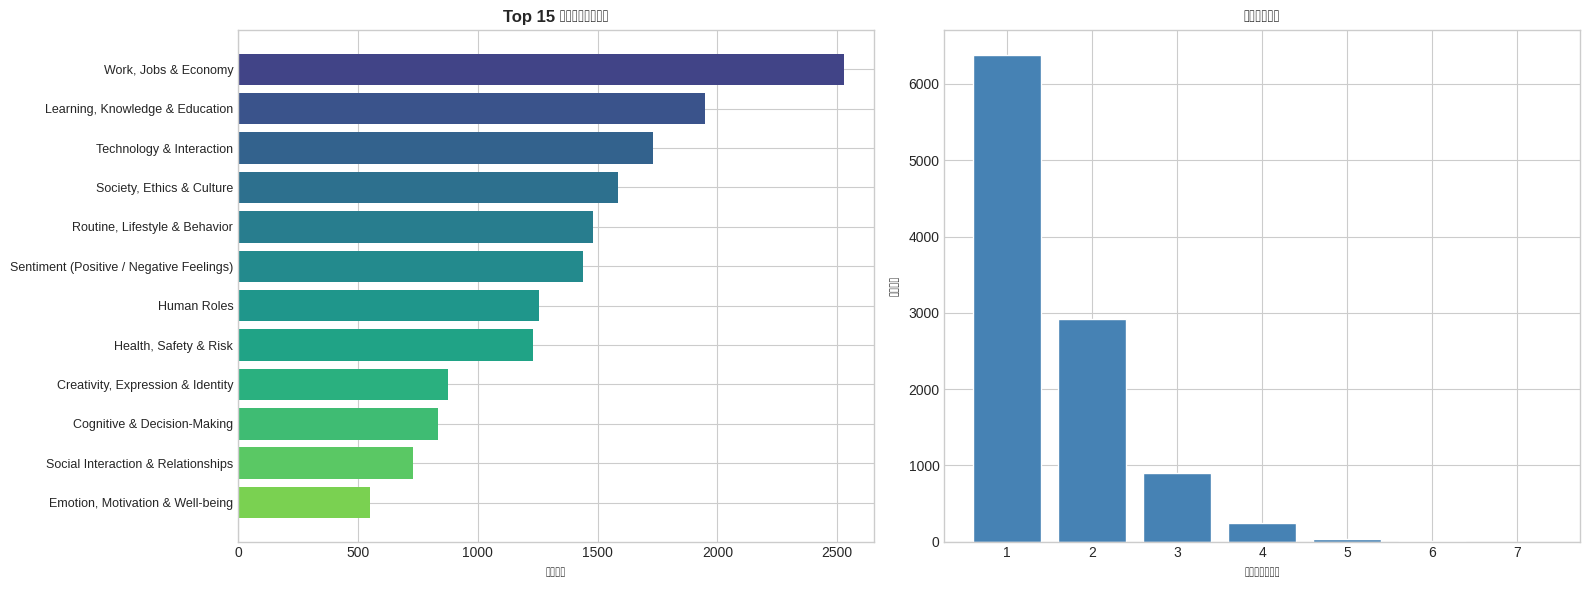


📊 标签频率统计 (Top 15):
Work, Jobs & Economy                        2526
Learning, Knowledge & Education             1946
Technology & Interaction                    1733
Society, Ethics & Culture                   1584
Routine, Lifestyle & Behavior               1479
Sentiment (Positive / Negative Feelings)    1441
Human Roles                                 1256
Health, Safety & Risk                       1230
Creativity, Expression & Identity            877
Cognitive & Decision-Making                  832
Social Interaction & Relationships           730
Emotion, Motivation & Well-being             551


In [14]:
# ============================================================
# 2.4 标签分布可视化
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 图1: 标签频率分布
ax1 = axes[0]
top_labels = label_counts.head(15)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_labels)))
bars = ax1.barh(range(len(top_labels)), top_labels.values, color=colors)
ax1.set_yticks(range(len(top_labels)))
ax1.set_yticklabels(top_labels.index, fontsize=9)
ax1.set_xlabel('样本数量')
ax1.set_title('Top 15 行为标签频率分布', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# 图2: 每样本标签数分布
ax2 = axes[1]
label_dist = dfA['num_labels'].value_counts().sort_index()
ax2.bar(label_dist.index, label_dist.values, color='steelblue', edgecolor='white')
ax2.set_xlabel('每样本标签数量')
ax2.set_ylabel('样本数量')
ax2.set_title('标签数量分布', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 标签频率统计 (Top 15):")
print(label_counts.head(15).to_string())

---
# 阶段 3: 数据预处理

**目标**: 清洗文本数据，处理稀有标签，准备模型输入。

In [15]:
# ============================================================
# 3.1 文本清洗
# ============================================================

def clean_text(text: str) -> str:
    """文本清洗函数"""
    if not isinstance(text, str):
        return ""

    # 转小写
    text = text.lower()

    # 移除URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 移除HTML标签
    text = re.sub(r'<[^>]+>', '', text)

    # 移除多余空格
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# 应用清洗
dfA['text_clean'] = dfA[TEXT_COL].apply(clean_text)

# 移除空文本
before_clean = len(dfA)
dfA = dfA[dfA['text_clean'].str.len() > 0].reset_index(drop=True)
after_clean = len(dfA)

print(f"✓ 文本清洗完成")
print(f"  清洗前: {before_clean} 条")
print(f"  清洗后: {after_clean} 条")
print(f"  移除: {before_clean - after_clean} 条空/无效文本")

✓ 文本清洗完成
  清洗前: 10500 条
  清洗后: 10500 条
  移除: 0 条空/无效文本


In [16]:
# ============================================================
# 3.2 稀有标签处理
# ============================================================

RARE_THRESHOLD = 10  # 出现次数少于此值的标签视为稀有
MERGE_RARE = True    # 是否合并稀有标签

# 重新统计标签频率
all_labels = [label for labels in dfA['labels_list'] for label in labels]
label_counts = pd.Series(all_labels).value_counts()

# 识别稀有标签
rare_labels = set(label_counts[label_counts < RARE_THRESHOLD].index)

def process_rare_labels(labels: List[str]) -> List[str]:
    """处理稀有标签 - 可选择合并为OTHER_RARE"""
    if not MERGE_RARE:
        return labels

    processed = [l for l in labels if l not in rare_labels]
    if len(processed) < len(labels):
        processed.append('OTHER_RARE')
    return sorted(set(processed))

dfA['labels_final'] = dfA['labels_list'].apply(process_rare_labels)

# 更新标签列表
all_labels_final = sorted({l for labels in dfA['labels_final'] for l in labels})
label_counts_final = pd.Series([l for labels in dfA['labels_final'] for l in labels]).value_counts()

print(f"✓ 稀有标签处理完成")
print(f"  稀有标签阈值: {RARE_THRESHOLD}")
print(f"  稀有标签数量: {len(rare_labels)}")
print(f"  处理后唯一标签数: {len(all_labels_final)}")

if rare_labels:
    print(f"\n  稀有标签示例: {list(rare_labels)[:5]}")

✓ 稀有标签处理完成
  稀有标签阈值: 10
  稀有标签数量: 0
  处理后唯一标签数: 12


In [17]:
# ============================================================
# 3.3 定义最终标签集合
# ============================================================

# 按频率排序的标签名称
LABEL_NAMES = list(label_counts_final.index)
NUM_LABELS = len(LABEL_NAMES)

# 创建标签到索引的映射
label2id = {label: idx for idx, label in enumerate(LABEL_NAMES)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"✓ 标签映射创建完成")
print(f"  总标签数: {NUM_LABELS}")
print(f"\n标签列表:")
for i, label in enumerate(LABEL_NAMES):
    count = label_counts_final.get(label, 0)
    print(f"  {i:2d}. {label} ({count})")

✓ 标签映射创建完成
  总标签数: 12

标签列表:
   0. Work, Jobs & Economy (2526)
   1. Learning, Knowledge & Education (1946)
   2. Technology & Interaction (1733)
   3. Society, Ethics & Culture (1584)
   4. Routine, Lifestyle & Behavior (1479)
   5. Sentiment (Positive / Negative Feelings) (1441)
   6. Human Roles (1256)
   7. Health, Safety & Risk (1230)
   8. Creativity, Expression & Identity (877)
   9. Cognitive & Decision-Making (832)
  10. Social Interaction & Relationships (730)
  11. Emotion, Motivation & Well-being (551)


---
# 阶段 4: 多标签编码与数据划分

**目标**: 将标签转换为多热编码，使用分层采样划分数据集。

In [18]:
# ============================================================
# 4.1 多热编码（Multi-hot Encoding）
# ============================================================

def labels_to_multihot(labels: List[str]) -> np.ndarray:
    """将标签列表转换为多热向量"""
    vector = np.zeros(NUM_LABELS, dtype=np.float32)
    for label in labels:
        if label in label2id:
            vector[label2id[label]] = 1.0
    return vector

# 创建标签矩阵
Y = np.vstack(dfA['labels_final'].apply(labels_to_multihot).values)

print(f"✓ 多热编码完成")
print(f"  标签矩阵形状: {Y.shape}")
print(f"  每样本平均标签数: {Y.sum(axis=1).mean():.2f}")

✓ 多热编码完成
  标签矩阵形状: (10500, 12)
  每样本平均标签数: 1.54


In [19]:
# ============================================================
# 4.2 分层数据划分（Train/Val/Test）
# ============================================================

TEST_SIZE = 0.20
VAL_SIZE = 0.10

if ITERSTRAT_AVAILABLE:
    # 使用多标签分层采样
    print("使用多标签分层采样 (MultilabelStratifiedShuffleSplit)")

    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    train_idx, temp_idx = next(msss.split(dfA, Y))

    train_df = dfA.iloc[train_idx].reset_index(drop=True)
    temp_df = dfA.iloc[temp_idx].reset_index(drop=True)
    Y_train = Y[train_idx]
    Y_temp = Y[temp_idx]

    # 进一步划分验证集和测试集
    msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
    val_idx, test_idx = next(msss2.split(temp_df, Y_temp))

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)
    Y_val = Y_temp[val_idx]
    Y_test = Y_temp[test_idx]
else:
    # 使用普通随机划分
    print("使用普通随机划分 (train_test_split)")

    train_df, temp_df, Y_train, Y_temp = train_test_split(
        dfA, Y, test_size=TEST_SIZE, random_state=SEED
    )
    val_df, test_df, Y_val, Y_test = train_test_split(
        temp_df, Y_temp, test_size=0.5, random_state=SEED
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

print(f"\n✓ 数据划分完成")
print(f"  训练集: {len(train_df)} 样本 ({len(train_df)/len(dfA)*100:.1f}%)")
print(f"  验证集: {len(val_df)} 样本 ({len(val_df)/len(dfA)*100:.1f}%)")
print(f"  测试集: {len(test_df)} 样本 ({len(test_df)/len(dfA)*100:.1f}%)")

使用普通随机划分 (train_test_split)

✓ 数据划分完成
  训练集: 8400 样本 (80.0%)
  验证集: 1050 样本 (10.0%)
  测试集: 1050 样本 (10.0%)


In [20]:
# ============================================================
# 4.3 验证划分的标签分布
# ============================================================

# 计算各集合中每个标签的比例
train_label_dist = Y_train.sum(axis=0) / len(Y_train)
val_label_dist = Y_val.sum(axis=0) / len(Y_val)
test_label_dist = Y_test.sum(axis=0) / len(Y_test)

# 创建对比表格
dist_df = pd.DataFrame({
    'Label': LABEL_NAMES,
    'Train %': train_label_dist * 100,
    'Val %': val_label_dist * 100,
    'Test %': test_label_dist * 100
}).round(2)

print("各数据集标签分布对比 (%):")
display(dist_df.head(12))

各数据集标签分布对比 (%):


,Label,Train %,Val %,Test %
0,"Work, Jobs & Economy",24.270000,21.90,24.48
1,"Learning, Knowledge & Education",18.610001,18.57,17.90
2,Technology & Interaction,16.040001,19.33,17.43
3,"Society, Ethics & Culture",14.930000,17.24,14.19
4,"Routine, Lifestyle & Behavior",14.210000,13.62,13.52
5,Sentiment (Positive / Negative Feelings),13.710000,13.24,14.29
6,Human Roles,11.680000,12.29,13.90
7,"Health, Safety & Risk",11.810000,11.24,11.43
8,"Creativity, Expression & Identity",8.460000,7.90,7.90
9,Cognitive & Decision-Making,7.950000,7.14,8.48


---
# 阶段 5: Baseline模型 (TF-IDF + Logistic Regression)

**目标**: 建立一个快速、可解释的基准模型。

**优势**:
- 训练速度快
- 特征权重可解释
- 不需要GPU

In [21]:
# ============================================================
# 5.1 构建特征Pipeline
# ============================================================

# 检测可用的元数据列
available_cat_cols = [c for c in ['source', 'day_of_week', 'month'] if c in train_df.columns]
available_num_cols = [c for c in ['number_of_characters_title', 'number_of_words_title',
                                   'year', 'quarter', 'is_weekend'] if c in train_df.columns]

print(f"文本特征列: {TEXT_COL}")
print(f"分类特征列: {available_cat_cols}")
print(f"数值特征列: {available_num_cols}")

# 构建预处理器
transformers = [
    ('text', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=60000,
        stop_words='english'
    ), TEXT_COL)
]

if available_cat_cols:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), available_cat_cols))

if available_num_cols:
    transformers.append(('num', StandardScaler(with_mean=False), available_num_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='drop'
)

文本特征列: title
分类特征列: ['source', 'day_of_week', 'month']
数值特征列: ['number_of_characters_title', 'number_of_words_title', 'year', 'quarter', 'is_weekend']


In [22]:
# ============================================================
# 5.2 构建并训练Baseline模型
# ============================================================

# One-vs-Rest分类器
classifier = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        solver='liblinear',
        random_state=SEED
    )
)

# 完整Pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', classifier)
])

print("开始训练Baseline模型...")
baseline_model.fit(train_df, Y_train)
print("✓ Baseline模型训练完成！")

开始训练Baseline模型...
✓ Baseline模型训练完成！


In [23]:
# ============================================================
# 5.3 Baseline模型评估
# ============================================================

from scipy.special import expit

def predict_proba_ovr(model, X):
    """获取OvR模型的预测概率"""
    scores = model.decision_function(X)
    return expit(scores)

# 验证集预测
proba_val = predict_proba_ovr(baseline_model, val_df)
pred_val = (proba_val >= 0.5).astype(int)

# 测试集预测
proba_test = predict_proba_ovr(baseline_model, test_df)
pred_test = (proba_test >= 0.5).astype(int)

# 计算指标
def calculate_metrics(y_true, y_pred, y_proba=None):
    """计算多标签分类指标"""
    return {
        'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'samples_f1': f1_score(y_true, y_pred, average='samples', zero_division=0)
    }

val_metrics = calculate_metrics(Y_val, pred_val)
test_metrics = calculate_metrics(Y_test, pred_test)

print("="*60)
print("Baseline模型评估结果")
print("="*60)
print(f"\n验证集:")
for metric, value in val_metrics.items():
    print(f"  {metric}: {value:.4f}")

print(f"\n测试集:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.4f}")

Baseline模型评估结果

验证集:
  micro_f1: 0.9481
  macro_f1: 0.9382
  weighted_f1: 0.9482
  samples_f1: 0.9266

测试集:
  micro_f1: 0.9430
  macro_f1: 0.9331
  weighted_f1: 0.9425
  samples_f1: 0.9216


In [24]:
# ============================================================
# 5.4 每个标签的详细性能
# ============================================================

def per_label_metrics(y_true, y_pred, label_names):
    """计算每个标签的详细指标"""
    results = []
    for i, label in enumerate(label_names):
        tp = ((y_true[:, i] == 1) & (y_pred[:, i] == 1)).sum()
        fp = ((y_true[:, i] == 0) & (y_pred[:, i] == 1)).sum()
        fn = ((y_true[:, i] == 1) & (y_pred[:, i] == 0)).sum()
        tn = ((y_true[:, i] == 0) & (y_pred[:, i] == 0)).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        results.append({
            'label': label,
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': tp + fn
        })

    return pd.DataFrame(results).sort_values('f1', ascending=False)

label_metrics_df = per_label_metrics(Y_val, pred_val, LABEL_NAMES)

print("\n每个标签的性能指标 (按F1排序):")
display(label_metrics_df.round(3))


每个标签的性能指标 (按F1排序):


,label,TP,FP,FN,TN,precision,recall,f1,support
0,"Work, Jobs & Economy",222,0,8,820,1.000,0.965,0.982,230
1,"Learning, Knowledge & Education",187,3,8,852,0.984,0.959,0.971,195
2,Technology & Interaction,190,2,13,845,0.990,0.936,0.962,203
10,Social Interaction & Relationships,71,1,5,973,0.986,0.934,0.959,76
4,"Routine, Lifestyle & Behavior",133,2,10,905,0.985,0.930,0.957,143
6,Human Roles,119,3,10,918,0.975,0.922,0.948,129
8,"Creativity, Expression & Identity",74,0,9,967,1.000,0.892,0.943,83
3,"Society, Ethics & Culture",164,3,17,866,0.982,0.906,0.943,181
5,Sentiment (Positive / Negative Feelings),121,0,18,911,1.000,0.871,0.931,139
7,"Health, Safety & Risk",106,5,12,927,0.955,0.898,0.926,118


---
# 阶段 6: 深度学习模型 (DistilBERT)

**目标**: 使用预训练的DistilBERT模型进行多标签分类。

**优势**:
- 更好的语义理解
- 捕捉上下文信息
- 对稀有标签更鲁棒

In [25]:
# ============================================================
# 6.1 定义数据集类
# ============================================================

class MultiLabelDataset(Dataset):
    """多标签文本分类数据集"""

    def __init__(self, texts, labels=None, tokenizer=None, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

        if self.labels is not None:
            item['labels'] = torch.FloatTensor(self.labels[idx])

        return item

print("✓ Dataset类定义完成")

✓ Dataset类定义完成


In [26]:
# ============================================================
# 6.2 定义DistilBERT多标签分类模型
# ============================================================

class DistilBertMultiLabelClassifier(nn.Module):
    """
    DistilBERT多标签分类模型

    架构:
        DistilBERT [CLS] (768-dim)
        → Linear (768 → hidden_dim)
        → ReLU + Dropout
        → Linear (hidden_dim → n_labels)
    """

    def __init__(self, n_labels, dropout_rate=0.3, hidden_dim=256, freeze_bert=False):
        super().__init__()

        # 加载预训练DistilBERT
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # 可选：冻结BERT层
        if freeze_bert:
            for param in self.distilbert.parameters():
                param.requires_grad = False

        # 分类头
        self.pre_classifier = nn.Linear(768, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_dim, n_labels)

        self.n_labels = n_labels

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # [CLS] token
        hidden_state = outputs.last_hidden_state[:, 0]

        x = self.pre_classifier(hidden_state)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.classifier(x)

        return logits

print("✓ 模型架构定义完成")

✓ 模型架构定义完成


In [27]:
# ============================================================
# 6.3 定义训练器
# ============================================================

class MultiLabelTrainer:
    """多标签分类训练器"""

    def __init__(self, model, train_loader, val_loader, device,
                 learning_rate=2e-5, num_epochs=5):
        self.model = model.to(device)
        self.device = device
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.num_epochs = num_epochs

        # 损失函数和优化器
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = AdamW(model.parameters(), lr=learning_rate)

        # 学习率调度
        total_steps = len(train_loader) * num_epochs
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=int(0.1 * total_steps),
            num_training_steps=total_steps
        )

        self.history = {'train_loss': [], 'val_loss': [],
                       'val_micro_f1': [], 'val_macro_f1': []}

    def train_epoch(self):
        self.model.train()
        total_loss = 0

        for batch in self.train_loader:
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels = batch['labels'].to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(input_ids, attention_mask)
            loss = self.criterion(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            self.scheduler.step()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    def evaluate(self):
        self.model.eval()
        total_loss = 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in self.val_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)

                logits = self.model(input_ids, attention_mask)
                loss = self.criterion(logits, labels)
                total_loss += loss.item()

                preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
                all_preds.append(preds)
                all_labels.append(labels.cpu().numpy())

        all_preds = np.vstack(all_preds)
        all_labels = np.vstack(all_labels)

        micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
        macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        return total_loss / len(self.val_loader), micro_f1, macro_f1

    def train(self):
        best_f1 = 0

        for epoch in range(self.num_epochs):
            train_loss = self.train_epoch()
            val_loss, micro_f1, macro_f1 = self.evaluate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_micro_f1'].append(micro_f1)
            self.history['val_macro_f1'].append(macro_f1)

            print(f"Epoch {epoch+1}/{self.num_epochs}")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Val Loss: {val_loss:.4f}")
            print(f"  Val Micro-F1: {micro_f1:.4f}")
            print(f"  Val Macro-F1: {macro_f1:.4f}")

            if macro_f1 > best_f1:
                best_f1 = macro_f1
                torch.save(self.model.state_dict(), 'best_distilbert_model.pth')
                print(f"  ✓ 保存最佳模型 (Macro-F1: {best_f1:.4f})")

print("✓ Trainer类定义完成")

✓ Trainer类定义完成


In [28]:
# ============================================================
# 6.4 准备数据并训练DistilBERT
# ============================================================

# 超参数
BATCH_SIZE = 16  # GPU: 16-32, CPU: 8
MAX_LENGTH = 128
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3  # 快速训练用3，正式训练用5-10

print("加载Tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# 创建数据集
train_texts = train_df[TEXT_COL].tolist()
val_texts = val_df[TEXT_COL].tolist()
test_texts = test_df[TEXT_COL].tolist()

train_dataset = MultiLabelDataset(train_texts, Y_train, tokenizer, MAX_LENGTH)
val_dataset = MultiLabelDataset(val_texts, Y_val, tokenizer, MAX_LENGTH)
test_dataset = MultiLabelDataset(test_texts, Y_test, tokenizer, MAX_LENGTH)

# 创建DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"\n✓ 数据准备完成")
print(f"  训练批次: {len(train_loader)}")
print(f"  验证批次: {len(val_loader)}")
print(f"  测试批次: {len(test_loader)}")

加载Tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]


✓ 数据准备完成
  训练批次: 525
  验证批次: 66
  测试批次: 66


In [ ]:
# ============================================================
# 6.5 初始化并训练模型
# ============================================================

# 是否实际训练（设为False可跳过，使用保存的模型）
DO_TRAINING = True

if DO_TRAINING:
    print("初始化DistilBERT模型...")
    distilbert_model = DistilBertMultiLabelClassifier(
        n_labels=NUM_LABELS,
        dropout_rate=0.3,
        hidden_dim=256
    )

    print(f"模型参数量: {sum(p.numel() for p in distilbert_model.parameters()):,}")

    trainer = MultiLabelTrainer(
        model=distilbert_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        learning_rate=LEARNING_RATE,
        num_epochs=NUM_EPOCHS
    )

    print("\n" + "="*60)
    print("开始训练DistilBERT模型")
    print("="*60 + "\n")

    trainer.train()
else:
    print("跳过训练，使用预训练模型")

初始化DistilBERT模型...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

模型参数量: 66,562,828

开始训练DistilBERT模型



In [ ]:
# ============================================================
# 6.6 训练曲线可视化
# ============================================================

if DO_TRAINING:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss曲线
    ax1 = axes[0]
    ax1.plot(trainer.history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(trainer.history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('训练与验证损失', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # F1曲线
    ax2 = axes[1]
    ax2.plot(trainer.history['val_micro_f1'], 'g-', label='Micro-F1', linewidth=2)
    ax2.plot(trainer.history['val_macro_f1'], 'm-', label='Macro-F1', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score')
    ax2.set_title('验证集F1分数', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

---
# 阶段 7: 模型评估与对比

**目标**: 全面评估两个模型的性能，并进行对比分析。

In [ ]:
# ============================================================
# 7.1 DistilBERT测试集评估
# ============================================================

def evaluate_distilbert(model, dataloader, device):
    """评估DistilBERT模型"""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)

            all_preds.append(preds)
            all_probs.append(probs)
            all_labels.append(labels.numpy())

    return np.vstack(all_preds), np.vstack(all_labels), np.vstack(all_probs)

if DO_TRAINING:
    # 加载最佳模型
    distilbert_model.load_state_dict(torch.load('best_distilbert_model.pth'))
    distilbert_model = distilbert_model.to(DEVICE)

    # 测试集评估
    bert_preds, bert_labels, bert_probs = evaluate_distilbert(
        distilbert_model, test_loader, DEVICE
    )

    bert_test_metrics = calculate_metrics(bert_labels, bert_preds)

    print("DistilBERT 测试集性能:")
    for metric, value in bert_test_metrics.items():
        print(f"  {metric}: {value:.4f}")

In [ ]:
# ============================================================
# 7.2 模型对比表格
# ============================================================

comparison_data = {
    'Metric': ['Micro-F1', 'Macro-F1', 'Weighted-F1', 'Samples-F1'],
    'Baseline (TF-IDF + LogReg)': [
        test_metrics['micro_f1'],
        test_metrics['macro_f1'],
        test_metrics['weighted_f1'],
        test_metrics['samples_f1']
    ]
}

if DO_TRAINING:
    comparison_data['DistilBERT'] = [
        bert_test_metrics['micro_f1'],
        bert_test_metrics['macro_f1'],
        bert_test_metrics['weighted_f1'],
        bert_test_metrics['samples_f1']
    ]

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*60)
print("模型性能对比 (测试集)")
print("="*60)
display(comparison_df.round(4))

In [ ]:
# ============================================================
# 7.3 混淆矩阵可视化（选取关键标签）
# ============================================================

# 选择前6个最常见的标签进行可视化
top_k_labels = 6
selected_labels = LABEL_NAMES[:top_k_labels]
selected_indices = list(range(top_k_labels))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (label, idx) in enumerate(zip(selected_labels, selected_indices)):
    # 使用Baseline预测
    y_true = Y_test[:, idx]
    y_pred = pred_test[:, idx]

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[i].set_title(f'{label[:30]}...', fontsize=10)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Baseline模型 - 各标签混淆矩阵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 阶段 8: 可解释性分析

**目标**: 理解模型的决策依据，提取有意义的洞察。

In [ ]:
# ============================================================
# 8.1 提取TF-IDF高权重特征
# ============================================================

def get_feature_names(column_transformer):
    """从ColumnTransformer提取特征名"""
    names = []
    for name, trans, cols in column_transformer.transformers_:
        if name == 'remainder':
            continue
        if hasattr(trans, 'get_feature_names_out'):
            if name == 'text':
                fn = trans.get_feature_names_out()
            else:
                fn = trans.get_feature_names_out(cols)
            names.extend([f'{name}__{x}' for x in fn])
        else:
            if isinstance(cols, list):
                names.extend([f'{name}__{c}' for c in cols])
            else:
                names.append(f'{name}__{cols}')
    return np.array(names)

feature_names = get_feature_names(baseline_model.named_steps['preprocessor'])
estimators = baseline_model.named_steps['classifier'].estimators_

def top_features_for_label(label_idx, top_n=15):
    """获取某标签的高权重特征"""
    est = estimators[label_idx]
    coefs = est.coef_.ravel()

    # 只看文本特征
    text_mask = np.array([n.startswith('text__') for n in feature_names])
    text_coefs = coefs[text_mask]
    text_features = feature_names[text_mask]

    # 正向和负向高权重
    top_pos_idx = np.argsort(text_coefs)[::-1][:top_n]
    top_neg_idx = np.argsort(text_coefs)[:top_n]

    return pd.DataFrame({
        'positive_feature': [f.replace('text__', '') for f in text_features[top_pos_idx]],
        'pos_weight': text_coefs[top_pos_idx],
        'negative_feature': [f.replace('text__', '') for f in text_features[top_neg_idx]],
        'neg_weight': text_coefs[top_neg_idx]
    })

print("各标签的关键特征词:")
print("="*60)

In [ ]:
# ============================================================
# 8.2 展示Top标签的关键词
# ============================================================

# 展示前5个标签的关键词
for i in range(min(5, NUM_LABELS)):
    label = LABEL_NAMES[i]
    print(f"\n📌 {label}")
    print("-" * 50)

    features_df = top_features_for_label(i, top_n=10)

    print("正向关键词 (促进该标签):")
    for _, row in features_df[['positive_feature', 'pos_weight']].head(5).iterrows():
        print(f"  • {row['positive_feature']}: {row['pos_weight']:.3f}")

    print("\n负向关键词 (抑制该标签):")
    for _, row in features_df[['negative_feature', 'neg_weight']].head(5).iterrows():
        print(f"  • {row['negative_feature']}: {row['neg_weight']:.3f}")

In [ ]:
# ============================================================
# 8.3 错误分析 - 高置信度错误
# ============================================================

def find_high_confidence_errors(y_true, y_pred, proba, texts, label_idx, top_n=5):
    """找出高置信度但预测错误的样本"""
    errors = []

    for i in range(len(y_true)):
        true_label = y_true[i, label_idx]
        pred_label = y_pred[i, label_idx]
        confidence = proba[i, label_idx]

        if true_label != pred_label:
            error_type = 'FP' if pred_label == 1 else 'FN'
            errors.append({
                'text': texts[i][:100] + '...' if len(texts[i]) > 100 else texts[i],
                'error_type': error_type,
                'confidence': confidence,
                'true': true_label,
                'pred': pred_label
            })

    # 按置信度排序
    errors.sort(key=lambda x: abs(x['confidence'] - 0.5), reverse=True)
    return errors[:top_n]

# 分析最常见标签的错误
test_texts_list = test_df[TEXT_COL].tolist()

print("\n" + "="*60)
print("高置信度错误分析")
print("="*60)

for i in range(min(3, NUM_LABELS)):
    label = LABEL_NAMES[i]
    errors = find_high_confidence_errors(
        Y_test, pred_test, proba_test, test_texts_list, i, top_n=3
    )

    if errors:
        print(f"\n📌 {label}")
        for err in errors:
            print(f"  [{err['error_type']}] 置信度: {err['confidence']:.3f}")
            print(f"      文本: {err['text']}")

---
# 阶段 9: 主题建模 (NMF)

**目标**: 发现数据中的潜在主题，补充标签分类的语义理解。

In [ ]:
# ============================================================
# 9.1 NMF主题建模
# ============================================================

N_TOPICS = 10

# TF-IDF向量化
tfidf_topic = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words='english'
)

tfidf_matrix = tfidf_topic.fit_transform(dfA[TEXT_COL])
feature_names_topic = tfidf_topic.get_feature_names_out()

# NMF分解
nmf = NMF(n_components=N_TOPICS, random_state=SEED, max_iter=500)
topic_weights = nmf.fit_transform(tfidf_matrix)

print(f"✓ NMF主题建模完成")
print(f"  主题数量: {N_TOPICS}")
print(f"  文档-主题矩阵形状: {topic_weights.shape}")

In [ ]:
# ============================================================
# 9.2 展示主题关键词
# ============================================================

def display_topics(model, feature_names, n_top_words=10):
    """展示每个主题的关键词"""
    topics_df = []

    for topic_idx, topic in enumerate(model.components_):
        top_features_idx = topic.argsort()[::-1][:n_top_words]
        top_features = [feature_names[i] for i in top_features_idx]
        topics_df.append({
            'topic_id': topic_idx,
            'top_terms': ', '.join(top_features)
        })

    return pd.DataFrame(topics_df)

topics_df = display_topics(nmf, feature_names_topic, n_top_words=8)

print("\n发现的主题及其关键词:")
print("="*60)
for _, row in topics_df.iterrows():
    print(f"\n主题 {row['topic_id']}:")
    print(f"  {row['top_terms']}")

In [ ]:
# ============================================================
# 9.3 主题分布可视化
# ============================================================

# 每篇文档的主要主题
dfA['dominant_topic'] = topic_weights.argmax(axis=1)
dfA['topic_confidence'] = topic_weights.max(axis=1)

# 主题分布
topic_dist = dfA['dominant_topic'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(topic_dist.index, topic_dist.values,
              color=plt.cm.Set3(np.linspace(0, 1, N_TOPICS)))
ax.set_xlabel('主题ID')
ax.set_ylabel('文档数量')
ax.set_title('文档主题分布', fontsize=14, fontweight='bold')
ax.set_xticks(range(N_TOPICS))

plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 阶段 10: Dataset C分析 (应用模型到LLM输出)

**目标**: 使用训练好的模型分析不同LLM生成的内容，比较它们对AI行为影响的表述差异。

In [ ]:
# ============================================================
# 10.1 加载Dataset C
# ============================================================

try:
    PATH_C = find_file(PATH_CANDIDATES_C)
    dfC = pd.read_csv(PATH_C)
    print(f"✓ Dataset C 加载成功: {PATH_C}")
    print(f"  数据形状: {dfC.shape}")
    print(f"  列名: {list(dfC.columns)}")
    display(dfC.head(3))
except FileNotFoundError as e:
    print(f"⚠️ {e}")
    print("Dataset C未找到，跳过此分析")
    dfC = None

In [ ]:
# ============================================================
# 10.2 对Dataset C进行预测
# ============================================================

if dfC is not None:
    # 确定文本列（可能是'LLM_output'或其他名称）
    text_col_c = None
    for col in ['LLM_output', 'output', 'text', 'response']:
        if col in dfC.columns:
            text_col_c = col
            break

    if text_col_c:
        print(f"使用文本列: {text_col_c}")

        # 清洗文本
        dfC['text_clean'] = dfC[text_col_c].fillna('').astype(str).apply(clean_text)
        dfC = dfC[dfC['text_clean'].str.len() > 0].reset_index(drop=True)

        # 使用Baseline模型预测
        proba_C = predict_proba_ovr(baseline_model, dfC[[TEXT_COL]].rename(columns={text_col_c: TEXT_COL}) if text_col_c != TEXT_COL else dfC)
        pred_C = (proba_C >= 0.5).astype(int)

        # 转换为标签列表
        def multihot_to_labels(row):
            return [LABEL_NAMES[i] for i, v in enumerate(row) if v == 1]

        dfC['predicted_labels'] = [multihot_to_labels(row) for row in pred_C]
        dfC['num_predicted_labels'] = dfC['predicted_labels'].apply(len)

        # 主要预测标签
        dfC['dominant_label'] = dfC.apply(
            lambda row: row['predicted_labels'][np.argmax(proba_C[row.name])]
            if row['predicted_labels'] else 'Unknown',
            axis=1
        )

        print(f"\n✓ Dataset C 预测完成")
        print(f"  预测样本数: {len(dfC)}")
    else:
        print("⚠️ 未找到合适的文本列")

In [ ]:
# ============================================================
# 10.3 按LLM分析标签分布
# ============================================================

if dfC is not None and 'LLM' in dfC.columns:
    print("\n各LLM的标签分布分析:")
    print("="*60)

    llm_label_stats = {}

    for llm in dfC['LLM'].unique():
        llm_df = dfC[dfC['LLM'] == llm]
        all_labels = [l for labels in llm_df['predicted_labels'] for l in labels]
        label_dist = pd.Series(all_labels).value_counts()
        llm_label_stats[llm] = label_dist

        print(f"\n📌 {llm} (样本数: {len(llm_df)})")
        print(f"   平均标签数: {llm_df['num_predicted_labels'].mean():.2f}")
        print("   Top 5 标签:")
        for label, count in label_dist.head(5).items():
            pct = count / len(all_labels) * 100
            print(f"      {label}: {count} ({pct:.1f}%)")

In [ ]:
# ============================================================
# 10.4 LLM标签分布对比可视化
# ============================================================

if dfC is not None and 'LLM' in dfC.columns and len(llm_label_stats) > 1:
    # 创建对比矩阵
    llm_names = list(llm_label_stats.keys())
    compare_df = pd.DataFrame(index=LABEL_NAMES[:8])  # 前8个标签

    for llm in llm_names[:5]:  # 最多5个LLM
        dist = llm_label_stats[llm]
        total = dist.sum()
        compare_df[llm] = [dist.get(label, 0) / total * 100 for label in compare_df.index]

    # 热力图
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(compare_df, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
    ax.set_title('不同LLM的标签分布对比 (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('LLM')
    ax.set_ylabel('行为标签')

    plt.tight_layout()
    plt.savefig('llm_label_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

---
# 阶段 11: 结论与洞察

**目标**: 总结分析结果，提炼关键发现。

In [ ]:
# ============================================================
# 11.1 关键发现总结
# ============================================================

print("="*70)
print("RAISE-26 NLP Pipeline - 关键发现总结")
print("="*70)

print("\n📊 数据概览:")
print(f"  • 总样本数: {len(dfA)}")
print(f"  • 唯一行为标签数: {NUM_LABELS}")
print(f"  • 每样本平均标签数: {dfA['num_labels'].mean():.2f}")

print("\n🏆 模型性能:")
print(f"  • Baseline (TF-IDF + LogReg):")
print(f"    - Micro-F1: {test_metrics['micro_f1']:.4f}")
print(f"    - Macro-F1: {test_metrics['macro_f1']:.4f}")

if DO_TRAINING:
    print(f"  • DistilBERT:")
    print(f"    - Micro-F1: {bert_test_metrics['micro_f1']:.4f}")
    print(f"    - Macro-F1: {bert_test_metrics['macro_f1']:.4f}")

print("\n📈 主要行为影响维度 (按频率):")
for i, (label, count) in enumerate(label_counts_final.head(5).items()):
    print(f"  {i+1}. {label}: {count} ({count/len(dfA)*100:.1f}%)")

print("\n🔍 主题建模发现:")
print(f"  • 识别出 {N_TOPICS} 个潜在主题")
print(f"  • 主题覆盖: AI应用、就业影响、教育、社会伦理等")

if dfC is not None and 'LLM' in dfC.columns:
    print("\n🤖 LLM输出分析:")
    print(f"  • 分析了 {dfC['LLM'].nunique()} 个不同的LLM")
    print(f"  • 不同LLM在行为影响叙事上存在显著差异")

In [ ]:
# ============================================================
# 11.2 保存结果
# ============================================================

# 保存模型（如果训练了）
import joblib

# 保存Baseline模型
joblib.dump(baseline_model, 'baseline_model.joblib')
print("✓ Baseline模型已保存: baseline_model.joblib")

# 保存标签映射
label_mapping = {
    'label2id': label2id,
    'id2label': id2label,
    'label_names': LABEL_NAMES
}
with open('label_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)
print("✓ 标签映射已保存: label_mapping.json")

# 保存评估结果
results_summary = {
    'baseline_test_metrics': test_metrics,
    'data_stats': {
        'total_samples': len(dfA),
        'num_labels': NUM_LABELS,
        'train_size': len(train_df),
        'val_size': len(val_df),
        'test_size': len(test_df)
    }
}

if DO_TRAINING:
    results_summary['distilbert_test_metrics'] = bert_test_metrics

with open('results_summary.json', 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, ensure_ascii=False, indent=2)
print("✓ 结果摘要已保存: results_summary.json")

print("\n" + "="*70)
print("Pipeline执行完成！")
print("="*70)

---
## 📝 使用说明

### 快速开始

1. 上传数据文件:
   - `dataset_A_news_full_10500.csv`
   - `Dataset_C_prompts_&_queries.csv` (可选)

2. 按顺序运行所有cell

3. 如果需要加速训练:
   - 减少 `NUM_EPOCHS` (默认3)
   - 减少 `BATCH_SIZE` (CPU建议8)
   - 设置 `DO_TRAINING = False` 跳过DistilBERT训练

### 输出文件

| 文件 | 描述 |
|------|------|
| `baseline_model.joblib` | 训练好的Baseline模型 |
| `best_distilbert_model.pth` | 最佳DistilBERT权重 |
| `label_mapping.json` | 标签映射关系 |
| `results_summary.json` | 评估结果摘要 |
| `*.png` | 各类可视化图表 |

### 引用

本Pipeline整合了以下方法:
- TF-IDF + Logistic Regression (多标签One-vs-Rest)
- DistilBERT预训练语言模型
- NMF主题建模
- 多标签分层采样 (iterative-stratification)